## Data Downloading

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d moazeldsokyx/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/moazeldsokyx/dogs-vs-cats
License(s): CC0-1.0
 92% 752M/817M [00:07<00:01, 51.9MB/s]
100% 817M/817M [00:07<00:00, 119MB/s] 


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

## Importing

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

## Generators

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 20000 files belonging to 2 classes.


In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/dataset/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 12461 files belonging to 2 classes.


## Normalize

In [ ]:
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image,label

  train_ds = train_ds.map(process)
  test_ds = test_ds.map(process)

## CNN Model

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
his = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 94ms/step - accuracy: 0.5965 - loss: 15.2705 - val_accuracy: 0.6525 - val_loss: 0.6307
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 91ms/step - accuracy: 0.5999 - loss: 0.6789 - val_accuracy: 0.6316 - val_loss: 0.6576
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.6538 - loss: 0.6329 - val_accuracy: 0.6482 - val_loss: 0.6469
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.6952 - loss: 0.5678 - val_accuracy: 0.6480 - val_loss: 0.7212
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7545 - loss: 0.4833 - val_accuracy: 0.6388 - val_loss: 0.9269
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - accuracy: 0.7988 - loss: 0.4204 - val_accuracy: 0.6232 - val_loss: 1.0199
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8529 - loss: 0.3256 - val_accuracy: 0.6317 - val_loss: 1.2367
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.8906 - loss: 0.2685 

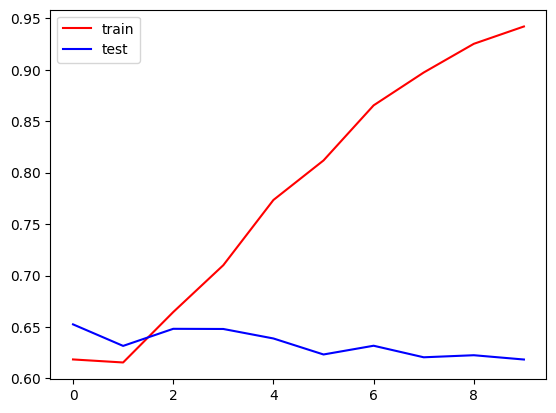

In [ ]:
import matplotlib.pyplot as plt

plt.plot(his.history['accuracy'], color='red', label= 'train')
plt.plot(his.history['val_accuracy'],color='blue', label= 'test')
plt.legend()
plt.show()

Here as the epoches increases training accuracy also is incerasing but the testing is remain constant say around ~0.52. Difference between train and test accurancy tells us that there is overfitting.

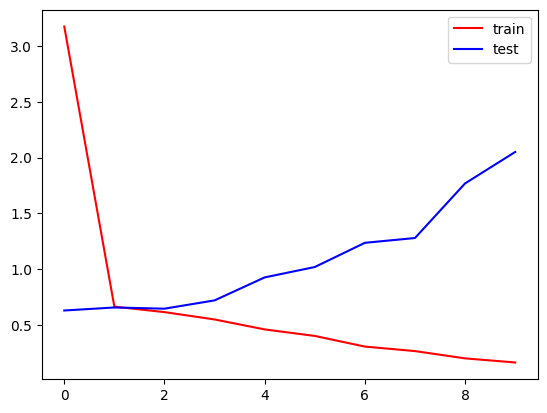

In [ ]:
plt.plot(his.history['loss'], color='red', label= 'train')
plt.plot(his.history['val_loss'],color='blue', label= 'test')
plt.legend()
plt.show()

Here as the epoches increases so training loss also is decreasing and the testing loss is also get reduce but not as much as train loss. Difference between train and test loss tells us that there is overfitting(not as much in training and testing accuracy).

## Optimization

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
his2 = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.5509 - loss: 1.9730 - val_accuracy: 0.5833 - val_loss: 0.7064
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.6604 - loss: 0.6184 - val_accuracy: 0.7327 - val_loss: 0.5307
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.7600 - loss: 0.4934 - val_accuracy: 0.7741 - val_loss: 0.4594
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - accuracy: 0.8144 - loss: 0.4105 - val_accuracy: 0.7731 - val_loss: 0.4731
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.8467 - loss: 0.3500 - val_accuracy: 0.7866 - val_loss: 0.4734
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.8762 - loss: 0.2832 - val_accuracy: 0.6880 - val_loss: 1.1171
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.9080 - loss: 0.2210 - val_accuracy: 0.7296 - val_loss: 0.8287
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.9407 - loss: 0

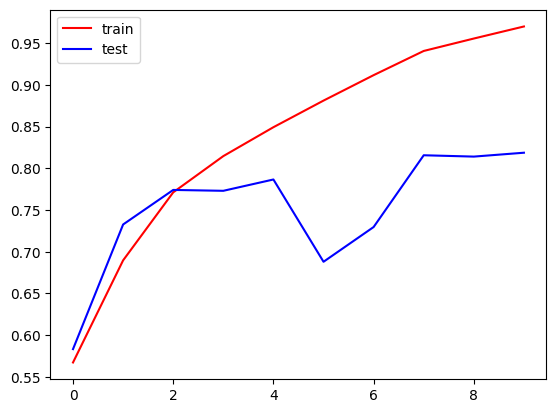

In [ ]:
plt.plot(his2.history['accuracy'], color='red', label= 'train')
plt.plot(his2.history['val_accuracy'],color='blue', label= 'test')
plt.legend()
plt.show()

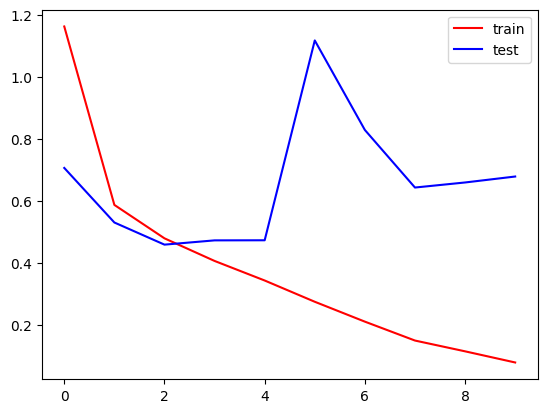

In [ ]:
plt.plot(his2.history['loss'], color='red', label= 'train')
plt.plot(his2.history['val_loss'],color='blue', label= 'test')
plt.legend()
plt.show()

## Predicting

In [ ]:
import cv2

In [ ]:
test_img = cv2.imread('/content/bernese-mountain-dog-puppy-walking-260nw-2484264021.jpg.webp')

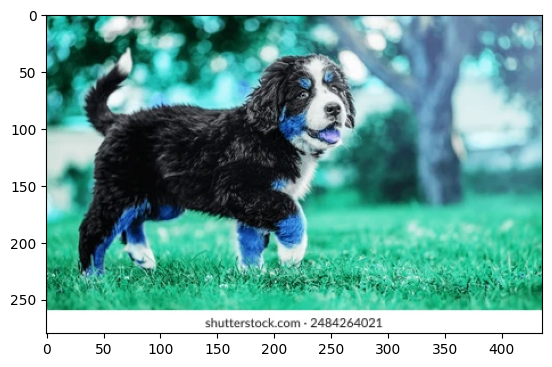

In [ ]:
plt.imshow(test_img)
plt.show()

In [ ]:
test_img.shape

(256, 256, 3)

In [ ]:
test_img = cv2.resize(test_img, (256,256))

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.5313841]], dtype=float32)

- The model output `array([[0.5313841]], dtype=float32)` represents the probability.
- For a binary classification with sigmoid activation, values > 0.5 typically indicate one class and < 0.5 the other.
- Since the input image is a dog and the probability is slightly above 0.5, the model predicts it as a dog.
- This prediction is considered correct for the input image.
- in simple words,

  (cat) 0 <----probability----> 1 (dog)

In [ ]:
test_img2 = cv2.imread('/content/baby-cat-one-month-old-looking-upward-24478582.jpg.webp')

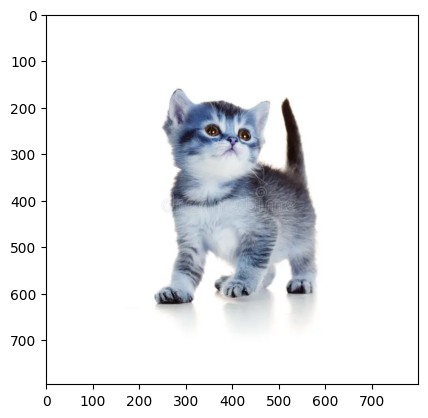

In [ ]:
plt.imshow(test_img2)
plt.show()

In [ ]:
test_img2.shape

(795, 800, 3)

In [ ]:
test_img2 = cv2.resize(test_img2, (256,256))

In [ ]:
test_input2 = test_img2.reshape((1,256,256,3))

In [ ]:
model.predict(test_input2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.00014487]], dtype=float32)

- The model's prediction is 0.00014487. As discussed earlier, for this binary classification model, values close to 0 likely represent a 'cat' and values close to 1 represent a 'dog'.
- Since the input image (test_img2) was a cat, this prediction, being very close to 0
- Indicates that the model is correctly classifying it as a cat.